# Volume Explorer

Generate a small synthetic volume, save it as OME-Zarr, and open it in the interactive QIM Volume Explorer web viewer with `qim3d.viz.volume_explorer`.

In [1]:
import os
import sys

import qim3d

## Install the Volume Explorer

The [QIM Volume Explorer](https://www.npmjs.com/package/@qim3d/volume-explorer) is a Node.js application for viewing 3D data. It needs `node` and `npm` to run. The cells below installs Node.js into the current Python environment from PyPI (`nodejs-wheel`) and configures the executable paths, so there is no need for admin rights or a system-wide installation.

In [2]:
!{sys.executable} -m pip install --quiet nodejs-wheel

The notebook's shell needs to find `node`, `npm` and, later, the `volume-explorer` command. They are all installed into this Python environment, so we put the environment's executable folders first on the `PATH`.

In [3]:
env_bin_dirs = [
    os.path.dirname(sys.executable),      # bin/ (Linux, macOS) or env root (Windows conda)
    os.path.join(sys.prefix, 'bin'),
    os.path.join(sys.prefix, 'Scripts'),  # Windows
    sys.prefix,                           # npm's global bin folder on Windows
]
os.environ['PATH'] = os.pathsep.join(env_bin_dirs + [os.environ['PATH']])

In [4]:
!node --version
!npm --version

v24.19.0
11.17.0


In [5]:
!npm install --global --prefix "{sys.prefix}" @qim3d/volume-explorer

npm warn Unknown global config "tmp". This will stop working in the next major version of npm. See `npm help npmrc` for supported config options.
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
changed 140 packages in 5s
⠙
⠙50 packages are looking for funding
⠙  run `npm fund` for details
⠙npm warn allow-scripts 1 package has install scripts not yet covered by allowScripts:
npm warn allow-scripts   esbuild@0.25.12 (postinstall: node install.js)
npm warn allow-scripts
npm warn allow-scripts Run `npm install -g --allow-scripts=esbuild` to allow these scripts once, or `npm config set allow-scripts=esbuild --location=user` to allow them for all global installs.
⠙

In [6]:
!volume-explorer --help

Usage: volume-explorer [source-url] [options]

Starts a local server for the packaged QIM Volume Explorer app.

Options:
  -p, --port <port>     Port to listen on (default: 4173)
  -H, --host <host>     Host/interface to bind (default: 127.0.0.1)
  -s, --src <url>       Dataset URL to preload
      --scale <value>   Initial scale level, for example 0, 1, or last
      --hidden          Start with the controls panel hidden
      --turntable       Enable turntable mode, pausing while hovered
      --open            Open the browser after starting
      --no-open         Do not open the browser after starting
  -h, --help            Show this help message

Examples:
  volume-explorer
  volume-explorer https://platform.qim.dk/qim-public/escargot/escargot.zarr
  volume-explorer --src https://example.org/sample.zarr --hidden --scale last


## Generate a small dataset

`qim3d.generate.volume_collection` places a number of synthetic blob-like objects into one volume. It's perfect to showcase the Volume Explorer.

In [7]:
volume, labels = qim3d.generate.volume_collection(
    n_volumes=12,
    collection_shape=(128, 128, 128),
    shape_range=((30, 30, 30), (45, 45, 45)),
    seed=0,
)

print(f'Volume: {volume.shape}, {volume.dtype}, {volume.nbytes / 1e6:.1f} MB')

Objects placed:   0%|          | 0/12 [00:00<?, ?it/s]

Volume: (128, 128, 128), uint8, 2.1 MB


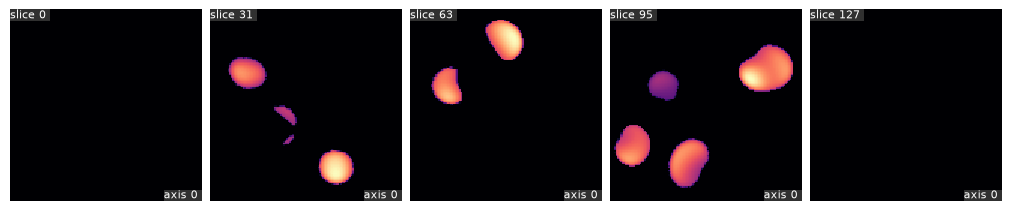

In [8]:
qim3d.viz.slices_grid(volume, n_slices=5)

## Save it as OME-Zarr

The Volume Explorer reads data over HTTP, and OME-Zarr works great with that. The volume is split into chunks and stored at several resolution levels, and the viewer only fetches what it needs.

In [9]:
NOTEBOOK_DIR = os.getcwd()
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'volume_explorer_data')
VOLUME_PATH = os.path.join(DATA_DIR, 'blobs.zarr')
LABELS_PATH = os.path.join(DATA_DIR, 'blobs_labels.zarr')

os.makedirs(DATA_DIR, exist_ok=True)

qim3d.io.export_ome_zarr(VOLUME_PATH, volume, chunk_size=64, replace=True)
qim3d.io.export_ome_zarr(LABELS_PATH, labels, chunk_size=64, replace=True)

Exporting data to OME-Zarr format at /home/ankov/playground/qim-demo-notebooks/volume_explorer_data/blobs.zarr
Number of scales: 2

Converting input data to Dask array
 - shape...: (128, 128, 128)
 - chunks..: (64, 64, 64)

Calculating the multi-scale pyramid
- Scale 0: (128, 128, 128)
- Scale 1: (64, 64, 64)
Writing data to disk


Saving:   0%|          | 0.00/9.00 [00:00<?, ?Chunks/s]


All done!
Exporting data to OME-Zarr format at /home/ankov/playground/qim-demo-notebooks/volume_explorer_data/blobs_labels.zarr
Number of scales: 2

Converting input data to Dask array
 - shape...: (128, 128, 128)
 - chunks..: (64, 64, 64)

Calculating the multi-scale pyramid
- Scale 0: (128, 128, 128)
- Scale 1: (64, 64, 64)
Writing data to disk


Saving:   0%|          | 0.00/9.00 [00:00<?, ?Chunks/s]


All done!


OME-Zarr is saved as an ordinary folder, and each resolution level is has its own sub-folder.

In [10]:
sorted(os.listdir(VOLUME_PATH))

['0', '1', 'zarr.json']

## Open the Volume Explorer

The cell below starts the local file server (port `8042` by default) that serves the folder containing the dataset.

It also starts the Volume Explorer (port `4173` by default), then opens the application in a new browser tab. (The visualization URL is also printed, in case the tab does not open by itself.)

**The cell keeps running while the viewer is open.** Stop the cell with the `Interrupt` button (or press `I` twice in command mode) to shut down the viewer.

Alternatively, if the data is already hosted, the source can be configured on https://viz.qim.dk.

In [11]:
qim3d.viz.volume_explorer(VOLUME_PATH)

QIM Volume Explorer is running at http://127.0.0.1:4173/
Serving static assets from /home/ankov/miniconda3/envs/qim3d-playground/lib/node_modules/@qim3d/volume-explorer/dist/app


Serving directory '/home/ankov/playground/qim-demo-notebooks/volume_explorer_data'
http://localhost:8042/

Visualization url:
http://localhost:4173/?src=http://localhost:8042/blobs.zarr

127.0.0.1 - - [24/Sep/2026 10:23:59] code 404, message File not found
127.0.0.1 - - [24/Sep/2026 10:23:59] "GET /blobs.zarr/.zattrs HTTP/1.1" 404 -
127.0.0.1 - - [24/Sep/2026 10:23:59] code 404, message File not found
127.0.0.1 - - [24/Sep/2026 10:23:59] "GET /blobs.zarr/.zgroup HTTP/1.1" 404 -
127.0.0.1 - - [24/Sep/2026 10:23:59] "GET /blobs.zarr/zarr.json HTTP/1.1" 200 -
127.0.0.1 - - [24/Sep/2026 10:23:59] "GET /blobs.zarr/0/zarr.json HTTP/1.1" 200 -
127.0.0.1 - - [24/Sep/2026 10:23:59] "GET /blobs.zarr/1/zarr.json HTTP/1.1" 200 -
127.0.0.1 - - [24/Sep/2026 10:23:59] "GET /blobs.zarr/0/c/0/0/0 HTTP/1.1" 200 -
127.0.0.1 - - [24/Sep/2026 10:23:59] "GET /blobs.zarr/0/c/1/0/0 HTTP/1.1" 200 -
127.0.0.1 - - [24/Sep/2026 10:23:59] "GET /blobs.zarr/0/c/0/1/0 HTTP/1.1" 200 -
127.0.0.1 - - [24/Sep/2026 10:23:


Stopped SIGINT.


KeyboardInterrupt: 

## Clean up

Deletes the generated data if you no longer need it. Restart the kernel to stop the background file servers.

In [12]:
import shutil

os.chdir(NOTEBOOK_DIR)
shutil.rmtree(DATA_DIR)